# Extracting "cognitive" signals from language models

This notebook will cover:

1. [Extracting surprisal](#1-extracting-surprisal)
2. [Extracting attention scores](#2-extracting-attention-scores)
3. [Extracting word embeddings](#3-extracting-word-embeddings)

We will use Hugging Face's [transformers](https://huggingface.co/docs/transformers/en/index) library.

The techniques shown in this notebook only do a single forward pass through the model, and the models are quite small, so you should be able to run everything on your laptop.

In [1]:
%pip install transformers torch

  Obtaining dependency information for transformers from https://files.pythonhosted.org/packages/96/88/beb33a79a382fcd2aed0be5222bdc47f41e4bfe7aaa90ae1374f1d8ea2af/transformers-4.53.2-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/40.9 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.9 kB ? eta -:--:--
     ---------------------------- --------- 30.7/40.9 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 40.9/40.9 kB 329.8 kB/s eta 0:00:00
  Obtaining dependency information for huggingface-hub<1.0,>=0.30.0 from https://files.pythonhosted.org/packages/46/7b/98daa50a2db034cab6cd23a3de04fa2358cb691593d28e9130203eb7a805/huggingface_hub-0.33.4-py3-none-any.whl.metadata
  Obtaining dependency information for tokenizers<0.22,>=0.21 from https://files.pythonhosted.org/packages/13/c3/cc2755ee10be859c4338c962a35b9a663788c0c0b50c0bdd8078fb6870cf/tokenizers-0.21.2-cp39-abi3-win_amd64.whl.metadata
  Obtaining dependency informat


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Extracting surprisal

Surprisal is the negative log-probability of a word given its left-hand context:

$surprisal(w_i) = -\log(P(w_i | w_1, w_2 \dots, w_{i-1}))$

In GPT-style transformer language models, the attention on the right-hand context is masked for every token, therefore the output probabilities for each token are only based on the left-hand context. This means that we can do a single forward pass with the entire text and get the surprisal values for each token at once, instead of having to do a forward pass for every single token.

Let's test this with GPT-2:

In [2]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

# Encode the input text
input_text = "Words are flowing out like endless rain into a paper cup"
inputs = tokenizer(input_text, return_tensors="pt")

# Generate output logits and convert to log-probabilities
with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits[0]
logprobs = F.log_softmax(logits, dim=-1)

# Get the log-probabilities of the true next tokens and convert to surprisals
next_token_input_ids = inputs.input_ids[0, 1:]
next_token_logprobs = logprobs.gather(1, next_token_input_ids.unsqueeze(-1)).squeeze(-1)
surprisal = -next_token_logprobs

# Print the surprisal values
for token_id, surprisal_value in zip(next_token_input_ids, surprisal):
    token = tokenizer.decode(token_id)
    print(f"{token!r}\t{surprisal_value.item()}")

C:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mert Yeşilyurt\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.co

' are'	5.057447910308838
' flowing'	9.223161697387695
' out'	3.208489179611206
' like'	5.142723560333252
' endless'	8.328278541564941
' rain'	4.032833099365234
' into'	4.367335319519043
' a'	2.6172609329223633
' paper'	9.718202590942383
' cup'	1.7952699661254883


Note that we don't get a surprisal value for the first word. This is because GPT-2 was trained without a BOS token. The first word in the sequence is *Words*, therefore the first predicted next token is the second word in the sequence (*are*).

Can you explain why certain words have high/low surprisal?

## 2. Extracting attention scores

Transformer language models usually have multiple layers and multiple attention heads within each layer. So for each token in the input sequence, we get a whole bunch of attention scores, making it more difficult to interpret them.

GPT-2 has 12 layers and 12 attention heads per layer:

In [3]:
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

for layer, attentions in enumerate(outputs.attentions, 1):
    print(f"Layer {layer}: {attentions.size()}")

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Layer 1: torch.Size([1, 12, 11, 11])
Layer 2: torch.Size([1, 12, 11, 11])
Layer 3: torch.Size([1, 12, 11, 11])
Layer 4: torch.Size([1, 12, 11, 11])
Layer 5: torch.Size([1, 12, 11, 11])
Layer 6: torch.Size([1, 12, 11, 11])
Layer 7: torch.Size([1, 12, 11, 11])
Layer 8: torch.Size([1, 12, 11, 11])
Layer 9: torch.Size([1, 12, 11, 11])
Layer 10: torch.Size([1, 12, 11, 11])
Layer 11: torch.Size([1, 12, 11, 11])
Layer 12: torch.Size([1, 12, 11, 11])


The first dimension in the tensors is the batch dimension. Can you explain what the other dimensions mean?

To simplify things, let's average the attention scores across all layers and heads and visualize them:

In [4]:
mean_attentions = torch.concatenate(outputs.attentions, dim=0).mean(dim=(0, 1))
mean_attentions.size()

torch.Size([11, 11])

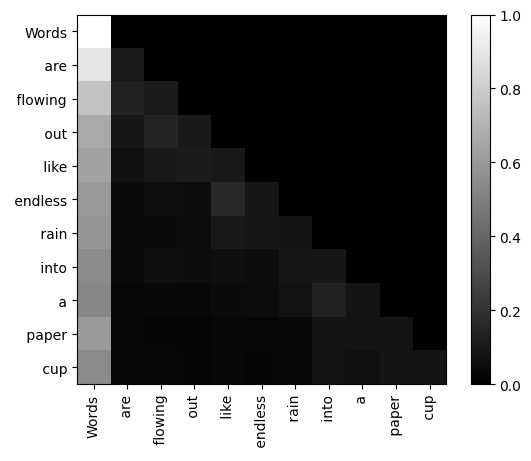

In [5]:
import matplotlib.pyplot as plt

plt.imshow(mean_attentions.numpy(), cmap='gray')
plt.colorbar()
tokens = [tokenizer.decode(token_id) for token_id in inputs.input_ids[0]]
plt.xticks(ticks=range(len(tokens)), labels=tokens, rotation=90)
plt.yticks(ticks=range(len(tokens)), labels=tokens)
plt.show()

Try to answer the following questions:

- Which token(s) receive(s) the most attention?
- Why is the upper right half completely black?
- Do the attention patterns look similar in all layers and attention heads? Can you find heads or layers with more interesting patterns?

## 3. Extracting word embeddings

Like most modern NLP models that process text input, the very first layer in a transformer model is a regular embedding layer:

In [6]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

Can you figure out what this model's vocabulary size is? And what is its embedding size?

While we *could* use the embeddings produced by the first layer as word representations, this is not be a very good representation of that word's meaning (can you explain why?). What people usually do is use hidden states from intermediate layers. Here's how you can access these:

In [7]:
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

for layer, hidden_states in enumerate(outputs.hidden_states, 1):
    print(f"Layer {layer}: {hidden_states.size()}")

Layer 1: torch.Size([1, 11, 768])
Layer 2: torch.Size([1, 11, 768])
Layer 3: torch.Size([1, 11, 768])
Layer 4: torch.Size([1, 11, 768])
Layer 5: torch.Size([1, 11, 768])
Layer 6: torch.Size([1, 11, 768])
Layer 7: torch.Size([1, 11, 768])
Layer 8: torch.Size([1, 11, 768])
Layer 9: torch.Size([1, 11, 768])
Layer 10: torch.Size([1, 11, 768])
Layer 11: torch.Size([1, 11, 768])
Layer 12: torch.Size([1, 11, 768])
Layer 13: torch.Size([1, 11, 768])


Again, the first dimension is the batch dimension.

Now, which layer(s) you use for your representation depends on your use case. The early layers tend to contain less information about context, while the very last layer mainly contains information about the next word to be predicted. A common approach is to average the last couple of layers (see, for example, Table 7 in the original BERT paper: [Devlin et al., 2019](https://doi.org/10.18653/v1/N19-1423)):

In [8]:
embeddings = outputs.hidden_states[-4:]  # Use the last 4 layers
mean_embedding = torch.mean(torch.concatenate(embeddings), dim=0)
mean_embedding

tensor([[-1.0896,  0.1565,  0.1756,  ..., -0.3082, -0.5947, -0.6787],
        [ 0.6517,  4.2317, -2.0281,  ...,  0.8110,  0.8457,  0.6886],
        [-2.8836, -0.3816, -6.9148,  ...,  1.4235,  0.8932, -0.5807],
        ...,
        [-1.1905,  3.8336, -2.5413,  ...,  3.2669, -2.6217,  0.0326],
        [-3.5185, -0.6532, -1.5532,  ..., -2.1441, -0.1912, -2.0656],
        [ 0.9816,  3.2421, -4.2998,  ...,  1.6740,  1.6976, -3.2948]])

We have now extracted word embeddings from GPT-2. Since GPT-2 is a unidirectional language model, each embedding will only contain information about the word's left-hand context. To get bidirectionally contextualized embeddings, we would have to use a bidirectional model like BERT.

In [ ]:
# TODO: Use a BERT model to get bidirectionally contextualized embeddings